# EDA — Ticket Helpdesk Multilíngue (dataset de teste)

Exploração do dataset `data/testing_datasets/ticket_helpdesk_labeled_multi_languages_english_spain_french_german.csv`: tickets de helpdesk rotulados em 4 idiomas (inglês, espanhol, francês, alemão). É um dataset separado do pipeline principal (`customer_support_tickets.csv`) — schema, granularidade e finalidade diferentes — por isso mora em `data/testing_datasets/` em vez de `data/raw/`, e este notebook não depende de `make data` nem dos splits em `data/processed/`.

**Objetivo:** entender estrutura, qualidade e distribuições do dataset antes de decidir como usá-lo (candidato natural: conjunto de teste externo/multilíngue para um classificador de `queue`/`priority`, dado seu tamanho pequeno para treino).

**Índice**
1. Carregamento dos dados
2. Estrutura básica e granularidade
3. Valores ausentes
4. Distribuição de `queue`, `priority` e `language`
5. Cruzamentos: `queue` × `priority` × `language`
6. Texto: `subject` e `text` por idioma
7. `priority` no texto: há sinal aparente?
8. Resumo dos principais achados

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from customer_support_analytics.config import DATA_DIR

from sklearn.feature_extraction.text import TfidfVectorizer

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Paleta categórica com ordem fixa (identidade da série nunca é ciclada por rank/posição)
CATEGORICAL_PALETTE = [
    "#2a78d6",  # blue
    "#eb6834",  # orange
    "#1baf7a",  # aqua
    "#eda100",  # yellow
    "#e87ba4",  # magenta
    "#008300",  # green
    "#4a3aa7",  # violet
    "#e34948",  # red
]
BLUE = CATEGORICAL_PALETTE[0]

plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=CATEGORICAL_PALETTE),
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "grid.color": "#e1e0d9",
    "axes.grid": True,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "font.size": 11,
})

DATASET_PATH = DATA_DIR / "testing_datasets" / "ticket_helpdesk_labeled_multi_languages_english_spain_french_german.csv"

QUEUE_ORDER = ["Hardware", "Software", "Accounting"]
PRIORITY_ORDER = [1, 2, 3]
LANGUAGE_ORDER = ["en", "es", "fr", "de"]

2026-08-21 13:45:00.034 | INFO     | customer_support_analytics.config:<module>:11 - PROJ_ROOT path is: C:\Users\Micro\Documents\GitHub\estudo_customer_support


## 1. Carregamento dos dados

In [2]:
df = pd.read_csv(DATASET_PATH)
print(f"shape: {df.shape}")
df.head()

shape: (200, 8)


,queue,priority,software_used,hardware_used,accounting_category,language,subject,text
0,Hardware,2,NaN,Wireless Mouse,NaN,en,Wireless Mouse suddenly stops working,"Dear Support Team, I've been using the Wireles..."
1,Hardware,2,NaN,IP PBX,NaN,fr,Problème de connexions IP PBX,"Bonjour, nous rencontrons un problème avec not..."
2,Hardware,2,NaN,SFX-Netzteil,NaN,de,Problem mit meinem SFX-Netzteil,"Sehr geehrte Damen und Herren, mein SFX-Netzte..."
3,Accounting,2,NaN,NaN,Customer Inquiries::Technical Support,en,Invoice Adjustment Request,"Dear Customer Support,\nI recently received my..."
4,Software,2,Arbitrum,NaN,NaN,en,Issue with Arbitrum: UI not loading,"Hello Support Team,\nI've been experiencing an..."


In [3]:
df.dtypes

queue                    str
priority               int64
software_used            str
hardware_used            str
accounting_category      str
language                 str
subject                  str
text                     str
dtype: object

## 2. Estrutura básica e granularidade

Não existe uma coluna de ID — diferente do `customer_support_tickets.csv`, que tem `Ticket ID`. Cada linha é presumivelmente um ticket; confirmamos verificando duplicatas exatas e duplicatas de `text`/`subject`.

In [4]:
print(f"nº de linhas: {len(df)}")
print("linhas totalmente duplicadas:", df.duplicated().sum())
print("'text' duplicado:", df["text"].duplicated().sum())
print("'subject' duplicado:", df["subject"].duplicated().sum())

nº de linhas: 200
linhas totalmente duplicadas: 0
'text' duplicado: 0
'subject' duplicado: 0


Nenhuma duplicata exata, nem de `text` nem de `subject` — cada linha é um ticket único, apesar de não haver uma chave explícita.

## 3. Valores ausentes

`software_used`, `hardware_used` e `accounting_category` têm muitos nulos à primeira vista — mas a hipótese óbvia é que cada coluna só se aplica a uma `queue`. Confirmamos cruzando a contagem de não-nulos de cada coluna com `queue`.

In [5]:
missing = df.isna().sum().to_frame("nulos")
missing["% do total"] = (missing["nulos"] / len(df) * 100).round(1)
missing

,nulos,% do total
queue,0,0.0
priority,0,0.0
software_used,117,58.5
hardware_used,134,67.0
accounting_category,149,74.5
language,0,0.0
subject,0,0.0
text,0,0.0


In [6]:
non_null_by_queue = pd.DataFrame({
    "software_used": df.groupby("queue")["software_used"].apply(lambda s: s.notna().sum()),
    "hardware_used": df.groupby("queue")["hardware_used"].apply(lambda s: s.notna().sum()),
    "accounting_category": df.groupby("queue")["accounting_category"].apply(lambda s: s.notna().sum()),
}).reindex(QUEUE_ORDER)
non_null_by_queue

,software_used,hardware_used,accounting_category
queue,,,
Hardware,0,66,0
Software,83,0,0
Accounting,0,0,51


Confirmado: `software_used` só é preenchido em tickets da fila `Software`, `hardware_used` só em `Hardware`, `accounting_category` só em `Accounting` — cada coluna tem exatamente zero valores não-nulos fora da sua fila. A ausência é 100% estrutural (dependente de `queue`), não um problema de qualidade de dados nem uma lacuna aleatória — mesmo padrão de raciocínio já aplicado a `Resolution`/`First Response Time` em `1.1-cb-eda-train.ipynb`, só que aqui a regra é exata em vez de aproximada.

## 4. Distribuição de `queue`, `priority` e `language`

`priority` é numérica (1/2/3); **a documentação do dataset não especifica a direção da escala** (não é possível inferir com confiança, a partir dos dados, se 1 é a prioridade mais baixa ou a mais alta) — tratada aqui só como categórica ordenada por valor, sem atribuir semântica de "baixa"/"alta".

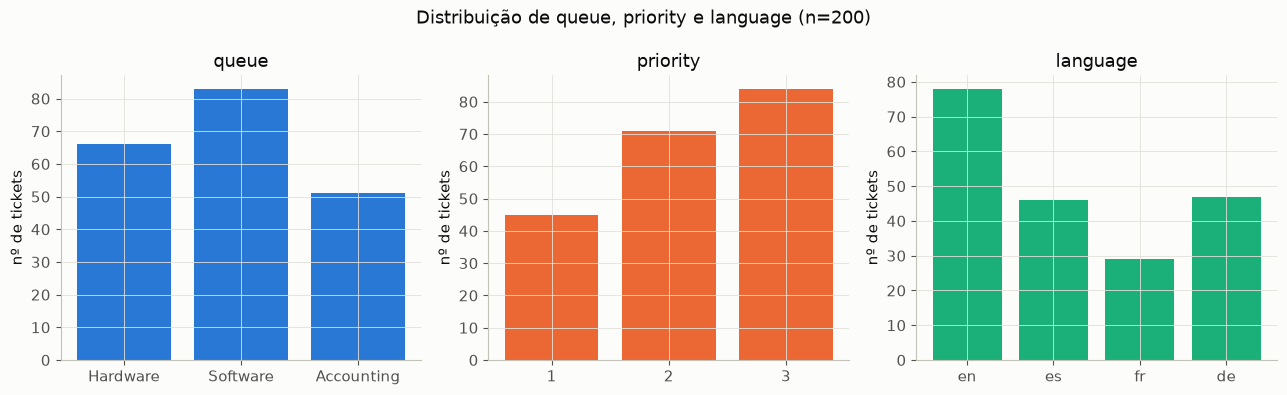

queue (%):
queue
Hardware      33.0
Software      41.5
Accounting    25.5
Name: count, dtype: float64

priority (%):
priority
1    22.5
2    35.5
3    42.0
Name: count, dtype: float64

language (%):
language
en    39.0
es    23.0
fr    14.5
de    23.5
Name: count, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

queue_counts = df["queue"].value_counts().reindex(QUEUE_ORDER)
axes[0].bar(queue_counts.index.astype(str), queue_counts.values, color=CATEGORICAL_PALETTE[0])
axes[0].set_title("queue")

priority_counts = df["priority"].value_counts().reindex(PRIORITY_ORDER)
axes[1].bar(priority_counts.index.astype(str), priority_counts.values, color=CATEGORICAL_PALETTE[1])
axes[1].set_title("priority")

language_counts = df["language"].value_counts().reindex(LANGUAGE_ORDER)
axes[2].bar(language_counts.index.astype(str), language_counts.values, color=CATEGORICAL_PALETTE[2])
axes[2].set_title("language")

for ax in axes:
    ax.set_ylabel("nº de tickets")
fig.suptitle(f"Distribuição de queue, priority e language (n={len(df)})")
plt.tight_layout()
plt.show()

print("queue (%):\n", (queue_counts / len(df) * 100).round(1), sep="")
print("\npriority (%):\n", (priority_counts / len(df) * 100).round(1), sep="")
print("\nlanguage (%):\n", (language_counts / len(df) * 100).round(1), sep="")

`queue` e `priority` têm alguma concentração (`Software` é a fila mais comum, `priority=3` é o valor mais comum), mas nenhuma classe fica rara o bastante para inviabilizar uma futura avaliação por classe. `language` é enviesado para `en` (~39%), com `es`/`de`/`fr` menos representados — `fr` é o menor grupo, com menos de 30 tickets.

## 5. Cruzamentos: `queue` × `priority` × `language`

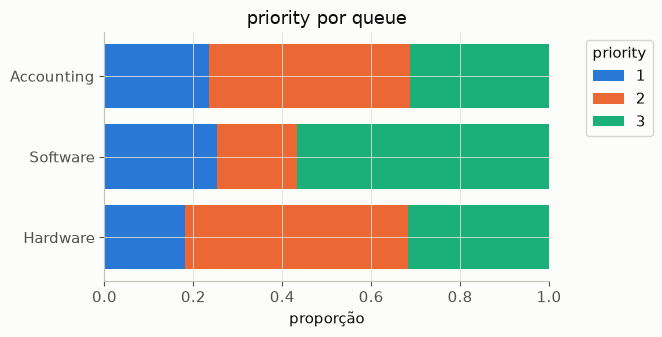

priority,1,2,3
queue,,,
Hardware,18.2,50.0,31.8
Software,25.3,18.1,56.6
Accounting,23.5,45.1,31.4


In [8]:
def stacked_share(data, row_col, col_col, row_order, col_order, palette):
    ct = pd.crosstab(data[row_col], data[col_col], normalize="index").reindex(index=row_order, columns=col_order)
    fig, ax = plt.subplots(figsize=(7, 3.5))
    left = np.zeros(len(ct))
    for val, color in zip(col_order, palette):
        ax.barh(ct.index.astype(str), ct[val], left=left, color=color, label=str(val))
        left += ct[val].to_numpy()
    ax.set_xlim(0, 1)
    ax.set_xlabel("proporção")
    ax.set_title(f"{col_col} por {row_col}")
    ax.legend(title=col_col, loc="upper right", bbox_to_anchor=(1.25, 1))
    plt.tight_layout()
    plt.show()
    return ct


ct_queue_priority = stacked_share(df, "queue", "priority", QUEUE_ORDER, PRIORITY_ORDER, CATEGORICAL_PALETTE)
(ct_queue_priority * 100).round(1)

`Software` se destaca: mais da metade dos seus tickets (56.6%) são `priority=3`, quase o dobro da proporção em `Hardware` (31.8%) e `Accounting` (31.4%) — possível associação real entre fila e prioridade, mas com n=200 (e menos ainda por fila) vale ler esse desvio com cautela.

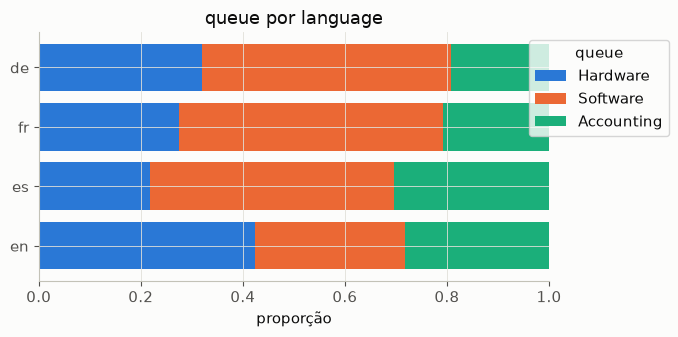

queue,Hardware,Software,Accounting
language,,,
en,42.3,29.5,28.2
es,21.7,47.8,30.4
fr,27.6,51.7,20.7
de,31.9,48.9,19.1


In [9]:
ct_language_queue = stacked_share(df, "language", "queue", LANGUAGE_ORDER, QUEUE_ORDER, CATEGORICAL_PALETTE)
(ct_language_queue * 100).round(1)

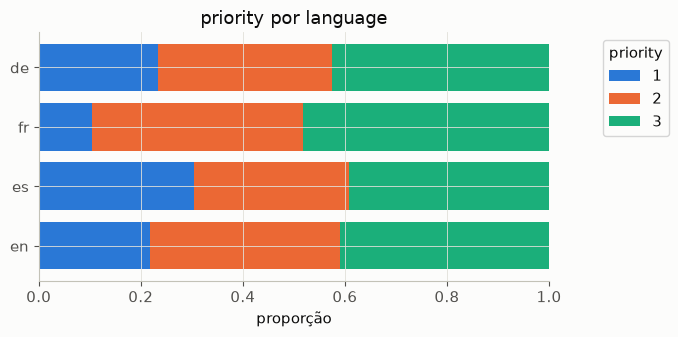

priority,1,2,3
language,,,
en,21.8,37.2,41.0
es,30.4,30.4,39.1
fr,10.3,41.4,48.3
de,23.4,34.0,42.6


In [10]:
ct_language_priority = stacked_share(df, "language", "priority", LANGUAGE_ORDER, PRIORITY_ORDER, CATEGORICAL_PALETTE)
(ct_language_priority * 100).round(1)

Aqui o retrato é misto. `queue` varia visivelmente por idioma: `en` é o único onde `Hardware` é a fila mais comum (42.3%), enquanto `es`/`fr`/`de` concentram claramente em `Software` (47.8-51.7%) — sinal de que `language` e `queue` não são independentes neste dataset. `priority` já varia menos entre idiomas, mas não é uniforme: `fr` se destaca com bem menos `priority=1` (10.3% vs. 21.8-30.4% nos demais) e mais `priority=3` (48.3%). Isso é relevante para qualquer uso futuro como teste multilíngue: o desbalanceamento de `language` (seção 4) **está parcialmente confundido com `queue`**, então uma métrica agregada por fila pode estar, na prática, medindo desempenho por idioma.

## 6. Texto: `subject` e `text` por idioma

Checagem rápida de tamanho de texto por idioma, útil para saber se `text`/`subject` têm volume comparável entre idiomas antes de usá-los como atributo (ex.: TF-IDF, contagem de tokens).

In [11]:
len_stats = pd.DataFrame({
    "subject (chars)": df["subject"].str.len(),
    "text (chars)": df["text"].str.len(),
    "text (palavras)": df["text"].str.split().str.len(),
})
len_stats.describe().round(1)

,subject (chars),text (chars),text (palavras)
count,200.0,200.0,200.0
mean,43.0,234.1,35.1
std,10.1,94.3,14.7
min,13.0,40.0,6.0
25%,36.0,159.2,23.8
50%,42.5,245.0,36.0
75%,49.0,302.8,46.2
max,79.0,427.0,69.0


In [12]:
by_lang = len_stats.groupby(df["language"]).mean().reindex(LANGUAGE_ORDER)
by_lang.round(1)

,subject (chars),text (chars),text (palavras)
language,,,
en,42.3,245.6,38.6
es,41.8,211.1,31.4
fr,45.3,235.0,34.0
de,44.0,237.0,33.6


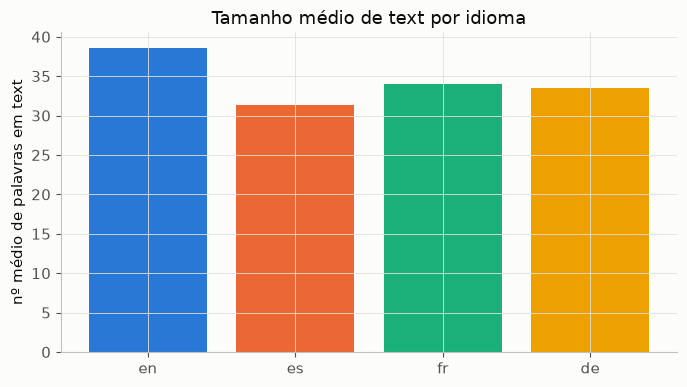

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(by_lang.index, by_lang["text (palavras)"], color=CATEGORICAL_PALETTE[:len(LANGUAGE_ORDER)])
ax.set_ylabel("nº médio de palavras em text")
ax.set_title("Tamanho médio de text por idioma")
plt.tight_layout()
plt.show()

Tamanho de texto comparável entre idiomas — `es` fica um pouco abaixo dos demais (~211 caracteres em média vs. ~235-246), mas a diferença é pequena e não parece indicar truncamento ou geração inconsistente entre idiomas.

## 7. `priority` no texto: há sinal aparente?

Mesma checagem feita em `2.0-cb-classificacao-prioridade.ipynb` (seção 3) para o dataset principal: contagem de palavras e termos de maior peso TF-IDF por classe de `priority`. Restrita ao subconjunto em inglês (`language == "en"`) — misturar os 4 idiomas no mesmo vocabulário TF-IDF apagaria qualquer sinal de conteúdo atrás do sinal (muito mais forte) de idioma.

In [14]:
word_count_en = df.loc[df["language"] == "en", "text"].str.split().str.len()
mean_words_en = word_count_en.groupby(df.loc[df["language"] == "en", "priority"]).mean().reindex(PRIORITY_ORDER)
print("nº médio de palavras em text, por priority (só en):")
print(mean_words_en.round(1))

nº médio de palavras em text, por priority (só en):
priority
1    31.9
2    42.1
3    39.1
Name: text, dtype: float64


In [15]:
df_en = df[df["language"] == "en"]
tfidf_probe = TfidfVectorizer(max_features=30, stop_words="english")
tfidf_matrix = tfidf_probe.fit_transform(df_en["text"])
terms = np.array(tfidf_probe.get_feature_names_out())

for priority in PRIORITY_ORDER:
    mask = (df_en["priority"] == priority).to_numpy()
    if mask.sum() == 0:
        continue
    mean_weights = np.asarray(tfidf_matrix[mask].mean(axis=0)).ravel()
    top_idx = mean_weights.argsort()[::-1][:8]
    print(f"priority={priority} (n={mask.sum()}): {', '.join(terms[top_idx])}")

priority=1 (n=17): hi, support, team, thanks, issue, ve, provide, invoice
priority=2 (n=29): team, support, dear, ve, issue, provide, hello, best
priority=3 (n=32): urgently, need, team, support, hello, regards, dear, tried


Diferente do dataset principal (onde o vocabulário de maior peso era quase idêntico entre classes), aqui aparece um indício de sinal: `priority=3` traz `urgently`/`need` entre os termos de maior peso, `priority=1` traz `thanks` (tom de encerramento/agradecimento), e `priority=2` fica no meio, sem termo de urgência nem de encerramento. Contagem média de palavras não é monotônica com `priority` (31.9 / 42.1 / 39.1), então não é um sinal de "tickets mais urgentes são mais longos". Com apenas ~78 tickets em inglês (17-32 por classe), é cedo para tratar isso como sinal robusto, mas é um indício que vale confirmar com mais dados antes de descartar o texto como atributo.

## 8. Resumo dos principais achados

- **Schema e escopo diferentes do pipeline principal:** 200 tickets, sem coluna de ID, colunas próprias (`queue`, `priority`, `software_used`/`hardware_used`/`accounting_category`, `language`, `subject`, `text`) — dataset independente de `customer_support_tickets.csv`, não passa por `dataset.py`/`make data`.
- **Sem duplicatas:** nenhuma linha, `text` ou `subject` duplicados.
- **Ausência 100% estrutural:** `software_used`, `hardware_used` e `accounting_category` são preenchidos exclusivamente na `queue` correspondente (Software/Hardware/Accounting) — não é dado faltando, é dado condicional ao tipo de ticket.
- **`priority` sem semântica documentada:** é numérica (1/2/3), mas a direção da escala (1 = mais baixa ou mais alta?) não pode ser inferida com confiança só a partir dos dados.
- **Classes com volume moderado:** `queue` e `priority` têm alguma concentração (mais tickets em `Software` e em `priority=3`) mas sem classes raras; `language` é enviesado para `en` (~39%), com `fr` como o menor grupo (~15%).
- **Possível associação `queue` × `priority`:** `Software` concentra quase o dobro da proporção de `priority=3` (56.6%) das outras filas (~31.5%) — vale investigar melhor com mais dados antes de tratar como sinal confiável (n pequeno por fila).
- **Idioma confundido com `queue`:** `en` concentra em `Hardware`, `es`/`fr`/`de` concentram em `Software` — o desbalanceamento de volume por idioma (seção 4) não é independente da fila, o que complica usar `queue` como métrica agregada num teste multilíngue. `priority` varia menos por idioma, mas `fr` também destoa (menos `priority=1`, mais `priority=3`).
- **Indício de sinal textual em `priority`** (checagem só em inglês, amostra pequena de 17-32 tickets por classe): `priority=3` traz termos de urgência (`urgently`, `need`) e `priority=1` traz tom de encerramento (`thanks`) — diferente do dataset principal, onde o vocabulário de maior peso era quase idêntico entre classes. Não é conclusivo com essa amostra, mas não deveria ser descartado sem checar em mais dados.
- **Uso sugerido:** dado o tamanho pequeno (n=200) e a natureza multilíngue, este dataset parece mais adequado como **conjunto de teste externo** (ex.: avaliar generalização multilíngue de um classificador de `queue`/`priority` treinado no dataset principal) do que como dataset de treino por si só — desde que a avaliação leve em conta o confundimento idioma×fila (seção 5) e não misture os dois num único número agregado sem checar por subgrupo.